===================== OLS RESULTS =====================
Equation   : y = 0.6410x + 0.9487
R-squared  : 0.7425
t-statistic: 1.6981
p-value    : 0.3388

=============== GRADIENT DESCENT RESULTS ===============
Equation   : y = 0.6410x + 0.9487
R-squared  : 0.7425
t-statistic: 1.6981
p-value    : 0.3388



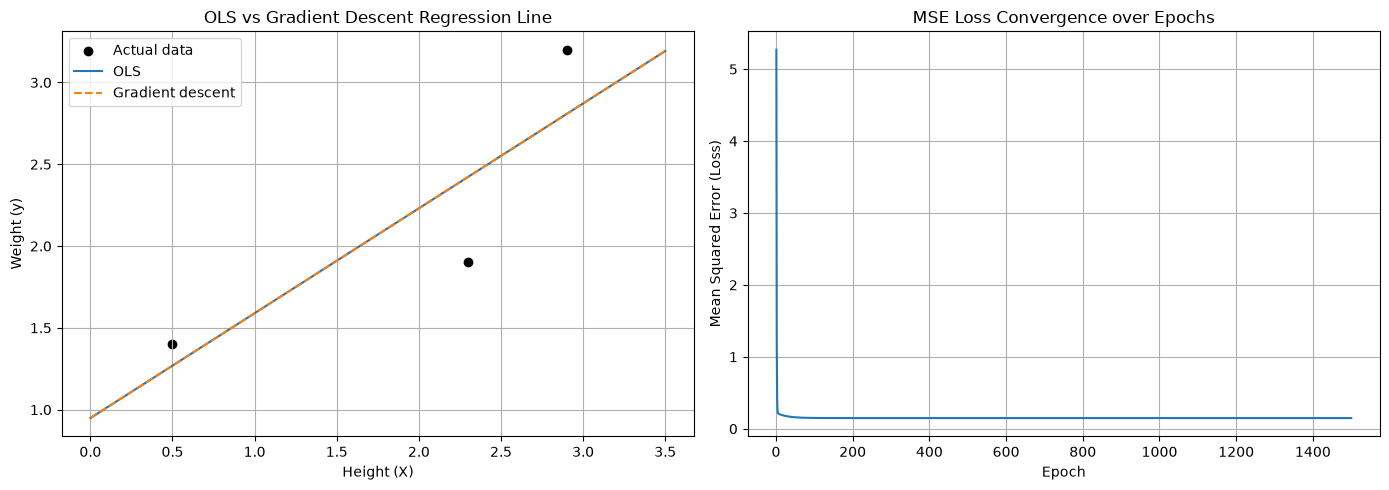

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =====================================================================
# Dataset Definition
# =====================================================================

X = np.array([0.5, 2.3, 2.9])
y = np.array([1.4, 1.9, 3.2])

# =====================================================================
# TASK 1: Ordinary Least Squares (OLS) Implementation
# =====================================================================

def ols_linear_regression(X, y):
    """
    Compute linear regression parameters analytically using OLS closed
    form formulas.

    Parameters:
        X (np.ndarray): Input feature vector (Height)
        y (np.ndarray): Target vector (Weight)

    Returns:
        m (float): Optimal slope
        c (float): Optimal intercept
    """
    x_mean = np.mean(X)
    y_mean = np.mean(y)
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    m = numerator / denominator
    c = y_mean - m * x_mean

    return m, c

# =====================================================================
# TASK 2: Batch Gradient Descent Implementation
# =====================================================================

def gradient_descent(X, y, alpha=0.05, epochs=1000):
    """
    Optimize linear regression parameters using batch gradient descent.
    """
    m = 0.0
    c = 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        y_pred = m * X + c
        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)
        dm = (-2 / n) * np.sum(X * (y - y_pred))
        dc = (-2 / n) * np.sum(y - y_pred)
        m -= alpha * dm
        c -= alpha * dc

    return m, c, loss_history

# =====================================================================
# TASK 3: Model Evaluation Metrics (R2, t-statistic, and p-value)
# =====================================================================

def compute_evaluation_metrics(X, y, y_pred, m):
    """Calculate R-squared and statistical significance of the slope."""
    n = len(X)
    df = n - 2
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    residual_variance = ss_res / df
    se_m = np.sqrt(residual_variance / np.sum((X - np.mean(X)) ** 2))
    t_stat = m / se_m
    p_val = 2 * stats.t.sf(np.abs(t_stat), df)
    return r2, t_stat, p_val

# =====================================================================
# TASK 4: Model Execution & Evaluation Comparison
# =====================================================================

if __name__ == "__main__":
    m_ols, c_ols = ols_linear_regression(X, y)
    y_pred_ols = m_ols * X + c_ols
    r2_ols, t_ols, p_ols = compute_evaluation_metrics(X, y, y_pred_ols, m_ols)

    print("===================== OLS RESULTS =====================")
    print(f"Equation   : y = {m_ols:.4f}x + {c_ols:.4f}")
    print(f"R-squared  : {r2_ols:.4f}")
    print(f"t-statistic: {t_ols:.4f}")
    print(f"p-value    : {p_ols:.4f}\n")

    alpha = 0.05
    epochs = 1500
    m_gd, c_gd, losses = gradient_descent(X, y, alpha=alpha, epochs=epochs)
    y_pred_gd = m_gd * X + c_gd
    r2_gd, t_gd, p_gd = compute_evaluation_metrics(X, y, y_pred_gd, m_gd)

    print("=============== GRADIENT DESCENT RESULTS ===============")
    print(f"Equation   : y = {m_gd:.4f}x + {c_gd:.4f}")
    print(f"R-squared  : {r2_gd:.4f}")
    print(f"t-statistic: {t_gd:.4f}")
    print(f"p-value    : {p_gd:.4f}\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(X, y, color="black", label="Actual data")
    x_vals = np.linspace(0, 3.5, 100)
    axes[0].plot(x_vals, m_ols * x_vals + c_ols, label="OLS")
    axes[0].plot(x_vals, m_gd * x_vals + c_gd, linestyle="--", label="Gradient descent")
    axes[0].set_title("OLS vs Gradient Descent Regression Line")
    axes[0].set_xlabel("Height (X)")
    axes[0].set_ylabel("Weight (y)")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(1, len(losses) + 1), losses)
    axes[1].set_title("MSE Loss Convergence over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Squared Error (Loss)")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()